In [1]:
!pip install nltk wordcloud scikit-learn

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
data = {
    'Review': [
        'The movie was fantastic and entertaining',
        'Excellent acting and wonderful storyline',
        'Amazing direction and great music',
        'I loved every scene of the movie',
        'The film was outstanding and enjoyable',
        'Brilliant performances and excellent screenplay',
        'Superb cinematography and engaging plot',
        'The movie exceeded my expectations',
        'The film was average and okay',
        'The storyline was normal and predictable',
        'It was neither good nor bad',
        'The movie was fine but nothing special',
        'The film was decent and watchable',
        'Acting was acceptable and the story was simple',
        'The movie had some good and some bad moments',
        'The film was ordinary and moderately entertaining',
        'Terrible movie with poor acting',
        'The storyline was boring and dull',
        'Worst movie I have ever seen',
        'The acting was disappointing',
        'Bad direction and waste of time',
        'The movie was slow and uninteresting',
        'Poor screenplay and weak performances',
        'The film was extremely boring and disappointing'
    ],
    'Sentiment': [
        'Positive','Positive','Positive','Positive',
        'Positive','Positive','Positive','Positive',
        'Neutral','Neutral','Neutral','Neutral',
        'Neutral','Neutral','Neutral','Neutral',
        'Negative','Negative','Negative','Negative',
        'Negative','Negative','Negative','Negative'
    ]
}

df = pd.DataFrame(data)
df.head()

,Review,Sentiment
0,The movie was fantastic and entertaining,Positive
1,Excellent acting and wonderful storyline,Positive
2,Amazing direction and great music,Positive
3,I loved every scene of the movie,Positive
4,The film was outstanding and enjoyable,Positive


In [4]:
df.to_csv("movie_reviews.csv", index=False)

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]
    return ' '.join(words)

df['Clean_Review'] = df['Review'].apply(preprocess)

df.head()

,Review,Sentiment,Clean_Review
0,The movie was fantastic and entertaining,Positive,movie fantastic entertaining
1,Excellent acting and wonderful storyline,Positive,excellent acting wonderful storyline
2,Amazing direction and great music,Positive,amazing direction great music
3,I loved every scene of the movie,Positive,loved every scene movie
4,The film was outstanding and enjoyable,Positive,film outstanding enjoyable


In [6]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Clean_Review'])
y = df['Sentiment']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         2
     Neutral       0.50      0.50      0.50         2
    Positive       0.00      0.00      0.00         1

    accuracy                           0.40         5
   macro avg       0.50      0.33      0.39         5
weighted avg       0.60      0.40      0.47         5



In [11]:
sentiment_count = df['Sentiment'].value_counts()
print(sentiment_count)

Sentiment
Positive    8
Neutral     8
Negative    8
Name: count, dtype: int64


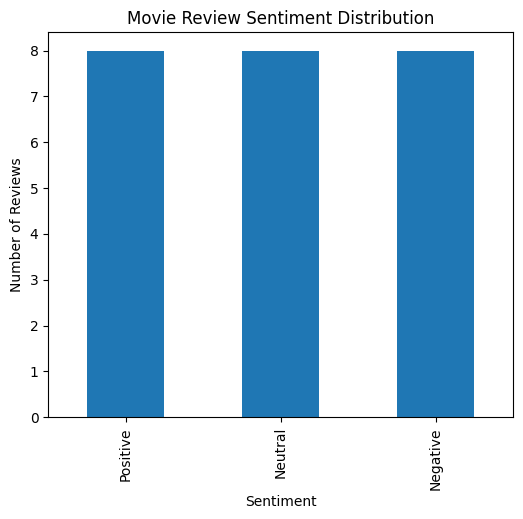

In [12]:
sentiment_count.plot(
    kind='bar',
    figsize=(6,5),
    title='Movie Review Sentiment Distribution'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

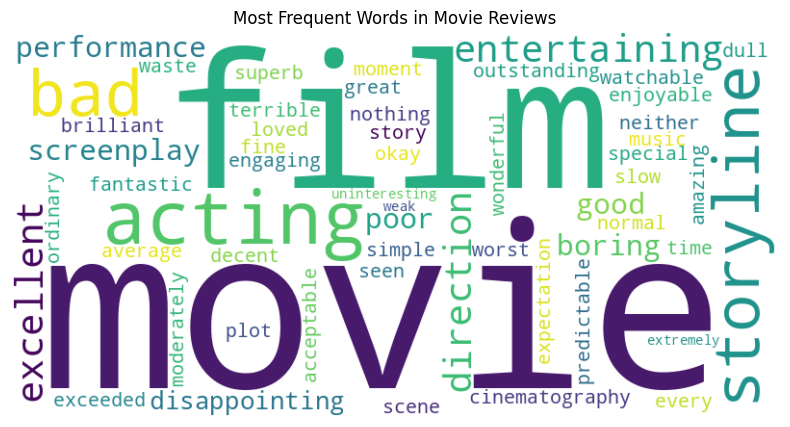

In [13]:
text = ' '.join(df['Clean_Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Movie Reviews')
plt.show()